
# Bayesian Geolocation with Uncertainty

Aquest notebook implementa:

- Generació de dades sintètiques
- Càlcul de la likelihood Bayesiana
- Obtenció de la posterior sobre una graella 2D
- Càlcul de la regió HPD del 95%
- Visualització amb heatmap


In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


## 1. Generació de dades sintètiques

In [2]:

# -------------------------
# CONFIGURACIÓ
# -------------------------

K = 6
sigma = 0.5

Lx, Ly = 10, 10

# Posició real desconeguda
x_true = np.array([6.5, 4.0])

# Posicions dels beacons
beacons = np.array([
    [0, 0],
    [0, 10],
    [10, 0],
    [10, 10],
    [5, 0],
    [0, 5]
])

# Distàncies reals
true_distances = np.linalg.norm(
    beacons - x_true,
    axis=1
)

# Observacions sorolloses
measurements = (
    true_distances
    + np.random.normal(0, sigma, K)
)

print("Mesures observades:")
for i, z in enumerate(measurements):
    print(f"Beacon {i}: {z:.3f}")


Mesures observades:
Beacon 0: 7.881
Beacon 1: 8.777
Beacon 2: 5.639
Beacon 3: 7.708
Beacon 4: 4.155
Beacon 5: 6.459


## 2. Visualització geomètrica

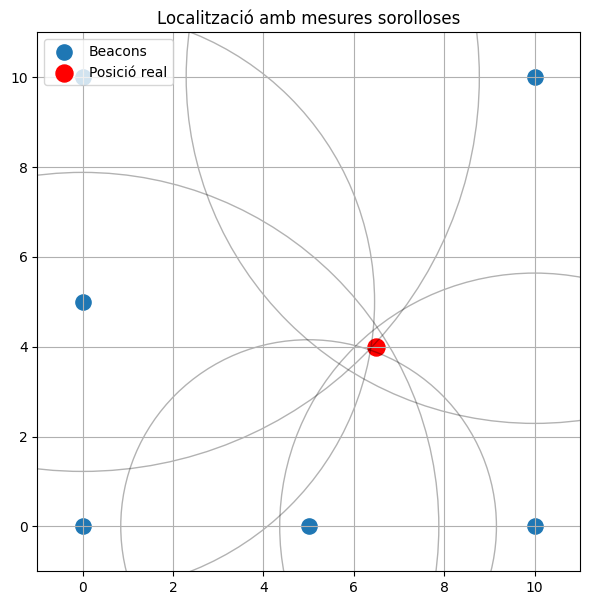

In [3]:

plt.figure(figsize=(7,7))

# Beacons
plt.scatter(
    beacons[:,0],
    beacons[:,1],
    s=120,
    label='Beacons'
)

# Posició real
plt.scatter(
    x_true[0],
    x_true[1],
    c='red',
    s=150,
    label='Posició real'
)

# Cercles observats
for i, beacon in enumerate(beacons):
    circle = plt.Circle(
        beacon,
        measurements[i],
        fill=False,
        alpha=0.3
    )
    plt.gca().add_artist(circle)

plt.xlim(-1, 11)
plt.ylim(-1, 11)

plt.grid(True)
plt.legend()
plt.title("Localització amb mesures sorolloses")
plt.show()


## 3. Graella espacial

In [4]:

# Graella 2D
N = 200

x_grid = np.linspace(0, Lx, N)
y_grid = np.linspace(0, Ly, N)

X, Y = np.meshgrid(x_grid, y_grid)

posterior = np.zeros_like(X)


## 4. Likelihood Bayesiana

In [5]:

def gaussian_pdf(z, mu, sigma):
    return (
        1 / np.sqrt(2 * np.pi * sigma**2)
    ) * np.exp(
        -(z - mu)**2 / (2 * sigma**2)
    )

# Likelihood sobre tota la graella
for i in range(N):
    for j in range(N):

        x = X[i, j]
        y = Y[i, j]

        likelihood = 1.0

        # Producte de likelihoods independents
        for k in range(K):

            bx, by = beacons[k]

            d = np.sqrt(
                (x - bx)**2 +
                (y - by)**2
            )

            likelihood *= gaussian_pdf(
                measurements[k],
                d,
                sigma
            )

        posterior[i, j] = likelihood

# Prior uniforme -> posterior proporcional a likelihood

# Normalització
posterior /= posterior.sum()


## 5. Regió HPD del 95%

In [6]:

# Aplanar posterior
flat = posterior.flatten()

# Ordenar de gran a petit
sorted_probs = np.sort(flat)[::-1]

# Suma acumulada
cumsum = np.cumsum(sorted_probs)

# Trobar threshold HPD
threshold = sorted_probs[cumsum >= 0.95][0]

# Màscara de la regió HPD
hpd_mask = posterior >= threshold

print(f"Threshold HPD: {threshold:.6e}")

# Probabilitat acumulada real
print(
    "Probabilitat acumulada:",
    posterior[hpd_mask].sum()
)


Threshold HPD: 2.301680e-04
Probabilitat acumulada: 0.9500214734691972


## 6. Heatmap de la posterior

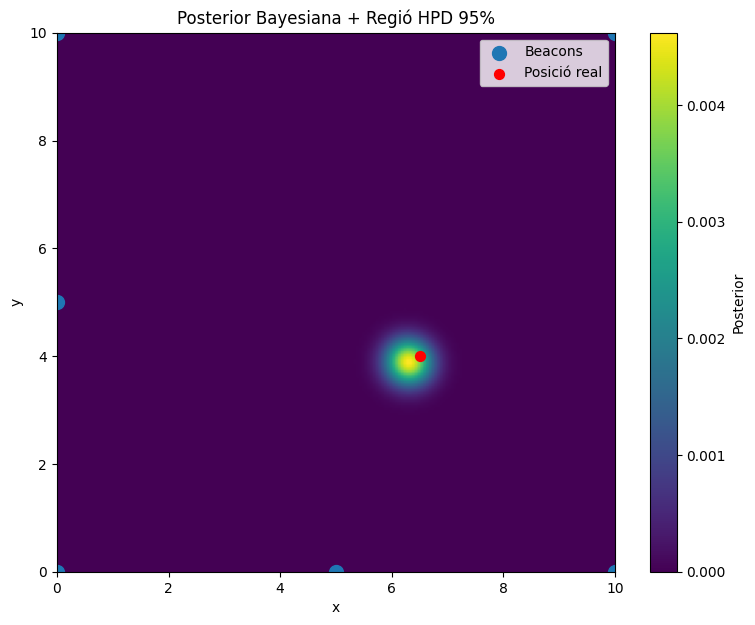

In [11]:

plt.figure(figsize=(9,7))

# Heatmap posterior
plt.imshow(
    posterior,
    extent=[0, Lx, 0, Ly],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label='Posterior')

# Contorn HPD 95%
plt.contour(
    X,
    Y,
    hpd_mask,
    levels=[10],
    linewidths=2
)

# Beacons
plt.scatter(
    beacons[:,0],
    beacons[:,1],
    s=100,
    label='Beacons'
)

# Posició real
plt.scatter(
    x_true[0],
    x_true[1],
    c='red',
    s=50,
    label='Posició real'
)

plt.xlabel("x")
plt.ylabel("y")

plt.title("Posterior Bayesiana + Regió HPD 95%")

plt.legend()
plt.show()



# Interpretació

- El heatmap representa la posterior:

\[
p(x,y \mid \mathbf z)
\]

- Les zones més brillants són les posicions més plausibles.

- El contorn representa la regió HPD del 95%.

- Aquesta regió conté el 95% de la probabilitat posterior.
